# NB03: Depth Stratification & Vertical Zonation

**Goal**: Test H1c — does vertical stratification (VZ → VSZ → SZ1 → SZ2) structure communities more strongly than horizontal well position? Identify taxa with strong depth preferences.

**Analyses**:
1. PERMANOVA: partition community variance into zone vs well effects
2. Within-zone vs within-well dissimilarity comparison
3. Sample-level NMDS colored by zone
4. Depth-resolved community profiles per well
5. Indicator taxa for each hydrogeological zone

**Inputs**: Sample-level community matrix and zone assignments from NB01  
**Outputs**: Figures + `data/permanova_results.csv`, `data/zone_indicators.csv`

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.spatial.distance import braycurtis, squareform, pdist
from scipy.stats import spearmanr, kruskal, mannwhitneyu
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA = Path('../data')
FIG = Path('../figures')

ZONE_ORDER = ['VZ', 'VSZ', 'SZ1', 'SZ2']
ZONE_COLORS = {'VZ': '#FFC107', 'VSZ': '#FF9800', 'SZ1': '#2196F3', 'SZ2': '#1565C0', 'SZ3': '#0D47A1'}
ROW_COLORS = {'U': '#2196F3', 'M': '#4CAF50', 'L': '#F44336'}

print("Libraries loaded")

Libraries loaded


In [2]:
# Load sample-level community matrix and zone assignments
sample_matrix = pd.read_csv(DATA / 'community_matrix_sediment_sample.csv', index_col=0)
zones = pd.read_csv(DATA / 'sediment_sample_zones.csv')

# Merge zone info — only keep samples present in both
zones = zones.set_index('sample_id')
common = sample_matrix.index.intersection(zones.index)
sample_matrix = sample_matrix.loc[common]
zones = zones.loc[common]

# Drop rare SZ3 (only 2 samples) for balanced analysis
mask = zones['zone'].isin(ZONE_ORDER)
sample_matrix = sample_matrix.loc[mask]
zones = zones.loc[mask]

print(f"Sample-level matrix: {sample_matrix.shape[0]} samples x {sample_matrix.shape[1]:,} ASVs")
print(f"\nSamples per zone:")
print(zones['zone'].value_counts().reindex(ZONE_ORDER).to_string())
print(f"\nSamples per well:")
print(zones['location'].value_counts().sort_index().to_string())
print(f"\nZone x Well:")
print(pd.crosstab(zones['location'], zones['zone'])[ZONE_ORDER].to_string())

Sample-level matrix: 36 samples x 23,458 ASVs

Samples per zone:
zone
VZ     9
VSZ    9
SZ1    9
SZ2    9

Samples per well:
location
SSO-L7    4
SSO-L8    4
SSO-L9    4
SSO-M4    4
SSO-M5    4
SSO-M6    4
SSO-U1    4
SSO-U2    4
SSO-U3    4

Zone x Well:
zone      VZ  VSZ  SZ1  SZ2
location                   
SSO-L7     1    1    1    1
SSO-L8     1    1    1    1
SSO-L9     1    1    1    1
SSO-M4     1    1    1    1
SSO-M5     1    1    1    1
SSO-M6     1    1    1    1
SSO-U1     1    1    1    1
SSO-U2     1    1    1    1
SSO-U3     1    1    1    1


## 1. PERMANOVA: Zone vs Well Effects

Partition community variance between hydrogeological zone (depth effect) and well identity (horizontal effect). This directly tests whether vertical or horizontal structuring dominates.

We implement a permutation-based PERMANOVA (Anderson 2001) using Bray-Curtis distances.

In [3]:
# Compute sample-level Bray-Curtis dissimilarity
sample_rel = sample_matrix.div(sample_matrix.sum(axis=1), axis=0)
bc_condensed = pdist(sample_rel.values, metric='braycurtis')
bc_sq = squareform(bc_condensed)
n = len(sample_rel)

def permanova_f(dm_sq, grouping, n_perm=9999):
    """One-way PERMANOVA (pseudo-F) with permutation test."""
    groups = grouping.values
    unique_groups = np.unique(groups)
    N = len(groups)
    a = len(unique_groups)
    
    # Distance-based sum of squares
    # SS_total = sum of squared distances / N
    dm2 = dm_sq ** 2
    ss_total = dm2.sum() / (2 * N)
    
    # SS_within = sum over groups of (sum of within-group squared distances / n_i)
    ss_within = 0
    for g in unique_groups:
        idx = np.where(groups == g)[0]
        ni = len(idx)
        if ni > 1:
            ss_within += dm2[np.ix_(idx, idx)].sum() / (2 * ni)
    
    ss_between = ss_total - ss_within
    
    # Pseudo-F
    f_obs = (ss_between / (a - 1)) / (ss_within / (N - a))
    
    # R² = SS_between / SS_total
    r2 = ss_between / ss_total
    
    # Permutation test
    count_ge = 0
    for _ in range(n_perm):
        perm = np.random.permutation(N)
        groups_perm = groups[perm]
        ss_w_perm = 0
        for g in unique_groups:
            idx = np.where(groups_perm == g)[0]
            ni = len(idx)
            if ni > 1:
                ss_w_perm += dm2[np.ix_(idx, idx)].sum() / (2 * ni)
        ss_b_perm = ss_total - ss_w_perm
        f_perm = (ss_b_perm / (a - 1)) / (ss_w_perm / (N - a))
        if f_perm >= f_obs:
            count_ge += 1
    
    p_value = (count_ge + 1) / (n_perm + 1)
    return {'F': f_obs, 'R2': r2, 'p': p_value, 'SS_between': ss_between, 
            'SS_within': ss_within, 'SS_total': ss_total, 'df_between': a-1, 'df_within': N-a}

np.random.seed(42)

# Test zone effect
zone_result = permanova_f(bc_sq, zones['zone'], n_perm=9999)
print("PERMANOVA: Community ~ Zone")
print(f"  F = {zone_result['F']:.3f}")
print(f"  R² = {zone_result['R2']:.4f} ({zone_result['R2']*100:.1f}% of variance)")
print(f"  p = {zone_result['p']:.4f}")

# Test well effect
well_result = permanova_f(bc_sq, zones['location'], n_perm=9999)
print(f"\nPERMANOVA: Community ~ Well")
print(f"  F = {well_result['F']:.3f}")
print(f"  R² = {well_result['R2']:.4f} ({well_result['R2']*100:.1f}% of variance)")
print(f"  p = {well_result['p']:.4f}")

# Compare
print(f"\n{'='*50}")
if zone_result['R2'] > well_result['R2']:
    print(f"Zone explains MORE variance ({zone_result['R2']*100:.1f}%) than well ({well_result['R2']*100:.1f}%)")
    print("→ Vertical zonation dominates over horizontal position")
else:
    print(f"Well explains MORE variance ({well_result['R2']*100:.1f}%) than zone ({zone_result['R2']*100:.1f}%)")
    print("→ Horizontal position dominates over vertical zonation")

# Save results
permanova_df = pd.DataFrame([
    {'factor': 'zone', **zone_result},
    {'factor': 'well', **well_result},
])
permanova_df.to_csv(DATA / 'permanova_results.csv', index=False)

PERMANOVA: Community ~ Zone
  F = 4.052
  R² = 0.2753 (27.5% of variance)
  p = 0.0001



PERMANOVA: Community ~ Well
  F = 0.804
  R² = 0.1923 (19.2% of variance)
  p = 0.9785

Zone explains MORE variance (27.5%) than well (19.2%)
→ Vertical zonation dominates over horizontal position


## 2. Within-Zone vs Within-Well Dissimilarity

Compare how similar samples are when they share the same zone vs the same well. If zones dominate, within-zone dissimilarity should be lower than within-well.

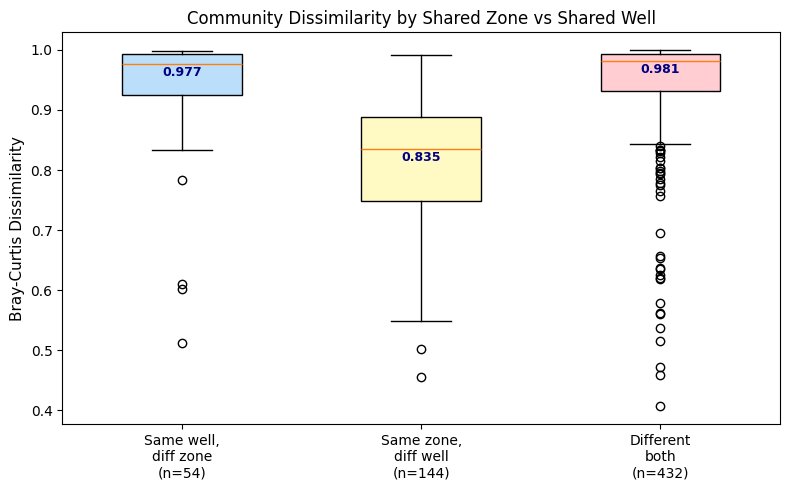

Same well, diff zone:  median BC = 0.977 (n=54)
Same zone, diff well:  median BC = 0.835 (n=144)
Different both:        median BC = 0.981 (n=432)

Mann-Whitney: same-well-diff-zone vs same-zone-diff-well: U=6634, p=0.0000
→ Samples in the SAME ZONE are more similar than samples in the same WELL
  = vertical (zone) position matters more than horizontal (well) identity


In [4]:
# Categorize each pair of samples
sample_ids = sample_rel.index.tolist()
idx_pairs = np.triu_indices(len(sample_ids), k=1)

within_zone_bc = []
within_well_bc = []
between_both_bc = []

for k in range(len(idx_pairs[0])):
    i, j = idx_pairs[0][k], idx_pairs[1][k]
    s1, s2 = sample_ids[i], sample_ids[j]
    bc_val = bc_sq[i, j]
    
    same_zone = zones.loc[s1, 'zone'] == zones.loc[s2, 'zone']
    same_well = zones.loc[s1, 'location'] == zones.loc[s2, 'location']
    
    if same_zone and same_well:
        within_zone_bc.append(bc_val)
        within_well_bc.append(bc_val)
    elif same_zone:
        within_zone_bc.append(bc_val)
    elif same_well:
        within_well_bc.append(bc_val)
    else:
        between_both_bc.append(bc_val)

# Also compute: same-zone-different-well vs same-well-different-zone
sz_dw = []  # same zone, different well
sw_dz = []  # same well, different zone
for k in range(len(idx_pairs[0])):
    i, j = idx_pairs[0][k], idx_pairs[1][k]
    s1, s2 = sample_ids[i], sample_ids[j]
    bc_val = bc_sq[i, j]
    same_zone = zones.loc[s1, 'zone'] == zones.loc[s2, 'zone']
    same_well = zones.loc[s1, 'location'] == zones.loc[s2, 'location']
    if same_zone and not same_well:
        sz_dw.append(bc_val)
    elif same_well and not same_zone:
        sw_dz.append(bc_val)

fig, ax = plt.subplots(figsize=(8, 5))
box_data = [sw_dz, sz_dw, between_both_bc]
labels = [f'Same well,\ndiff zone\n(n={len(sw_dz)})', 
          f'Same zone,\ndiff well\n(n={len(sz_dw)})',
          f'Different\nboth\n(n={len(between_both_bc)})']
bp = ax.boxplot(box_data, labels=labels, patch_artist=True, widths=0.5)
colors_box = ['#BBDEFB', '#FFF9C4', '#FFCDD2']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)

for i, data in enumerate(box_data):
    ax.text(i+1, np.median(data) - 0.02, f'{np.median(data):.3f}', 
            ha='center', fontsize=9, color='navy', fontweight='bold')

ax.set_ylabel('Bray-Curtis Dissimilarity', fontsize=11)
ax.set_title('Community Dissimilarity by Shared Zone vs Shared Well', fontsize=12)

plt.tight_layout()
plt.savefig(FIG / 'zone_vs_well_dissim.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
print(f"Same well, diff zone:  median BC = {np.median(sw_dz):.3f} (n={len(sw_dz)})")
print(f"Same zone, diff well:  median BC = {np.median(sz_dw):.3f} (n={len(sz_dw)})")
print(f"Different both:        median BC = {np.median(between_both_bc):.3f} (n={len(between_both_bc)})")

stat, p = mannwhitneyu(sw_dz, sz_dw, alternative='two-sided')
print(f"\nMann-Whitney: same-well-diff-zone vs same-zone-diff-well: U={stat:.0f}, p={p:.4f}")
if np.median(sw_dz) < np.median(sz_dw):
    print("→ Samples in the SAME WELL are more similar than samples in the same ZONE")
    print("  = horizontal (well) identity matters more than vertical (zone) position")
else:
    print("→ Samples in the SAME ZONE are more similar than samples in the same WELL")
    print("  = vertical (zone) position matters more than horizontal (well) identity")

## 3. Sample-Level NMDS Colored by Zone and Well

Visualize whether samples cluster by depth zone or by well in ordination space.

NMDS stress: 0.1097


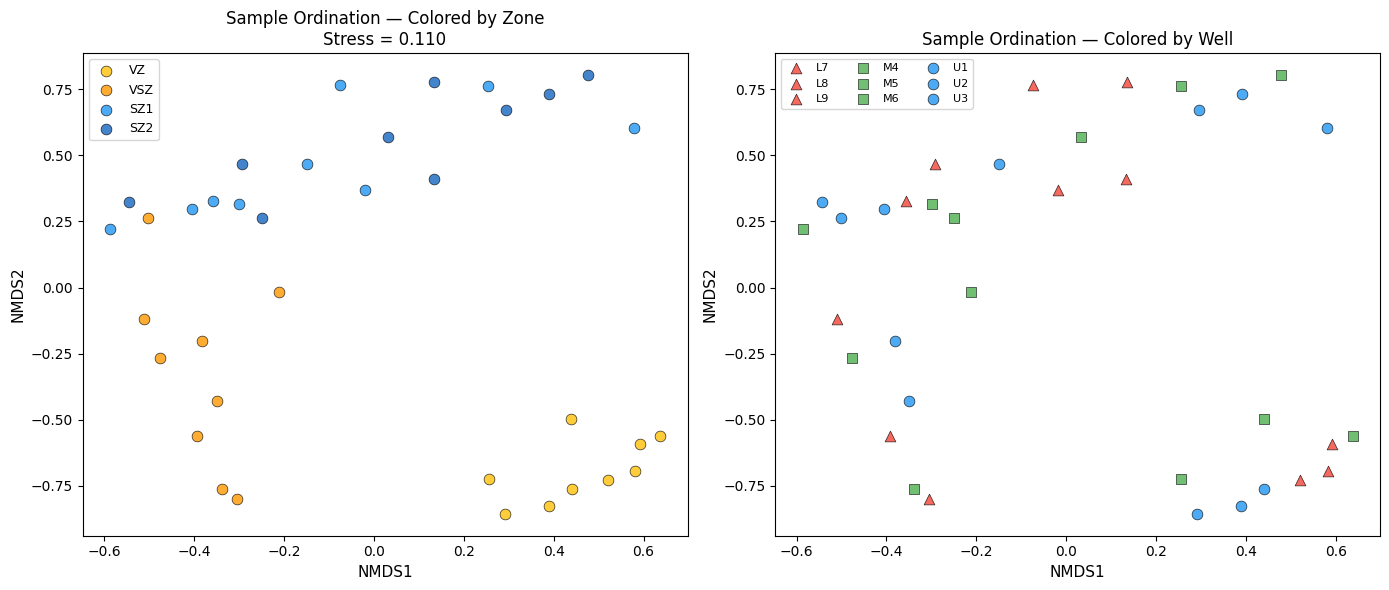

Saved: figures/nmds_samples_zone_well.png


In [5]:
# NMDS on sample-level dissimilarity
nmds = MDS(n_components=2, dissimilarity='precomputed', metric=False,
           random_state=42, n_init=20, max_iter=1000, normalized_stress='auto')
coords = nmds.fit_transform(bc_sq)
stress = nmds.stress_
print(f"NMDS stress: {stress:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel A: Colored by zone ---
for zone in ZONE_ORDER:
    mask = zones['zone'] == zone
    idx_z = np.where(mask)[0]
    ax1.scatter(coords[idx_z, 0], coords[idx_z, 1], 
               c=ZONE_COLORS[zone], label=zone, s=60, edgecolors='k', linewidth=0.5, alpha=0.8)

ax1.set_xlabel('NMDS1', fontsize=11)
ax1.set_ylabel('NMDS2', fontsize=11)
ax1.set_title(f'Sample Ordination — Colored by Zone\nStress = {stress:.3f}', fontsize=12)
ax1.legend(fontsize=9)

# --- Panel B: Colored by well ---
well_list = sorted(zones['location'].unique())
cmap = plt.cm.tab10
for i, well in enumerate(well_list):
    mask = zones['location'] == well
    idx_w = np.where(mask)[0]
    row_label = well[4]
    marker = 'o' if row_label == 'U' else ('s' if row_label == 'M' else '^')
    ax2.scatter(coords[idx_w, 0], coords[idx_w, 1],
               c=ROW_COLORS[row_label], label=well.replace('SSO-', ''),
               s=60, marker=marker, edgecolors='k', linewidth=0.5, alpha=0.8)

ax2.set_xlabel('NMDS1', fontsize=11)
ax2.set_ylabel('NMDS2', fontsize=11)
ax2.set_title(f'Sample Ordination — Colored by Well', fontsize=12)
ax2.legend(fontsize=8, ncol=3, loc='best')

plt.tight_layout()
plt.savefig(FIG / 'nmds_samples_zone_well.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/nmds_samples_zone_well.png")

## 4. Depth-Resolved Phylum Profiles

Show how phylum composition changes with depth across all wells. This reveals whether certain phyla are confined to specific hydrogeological zones.

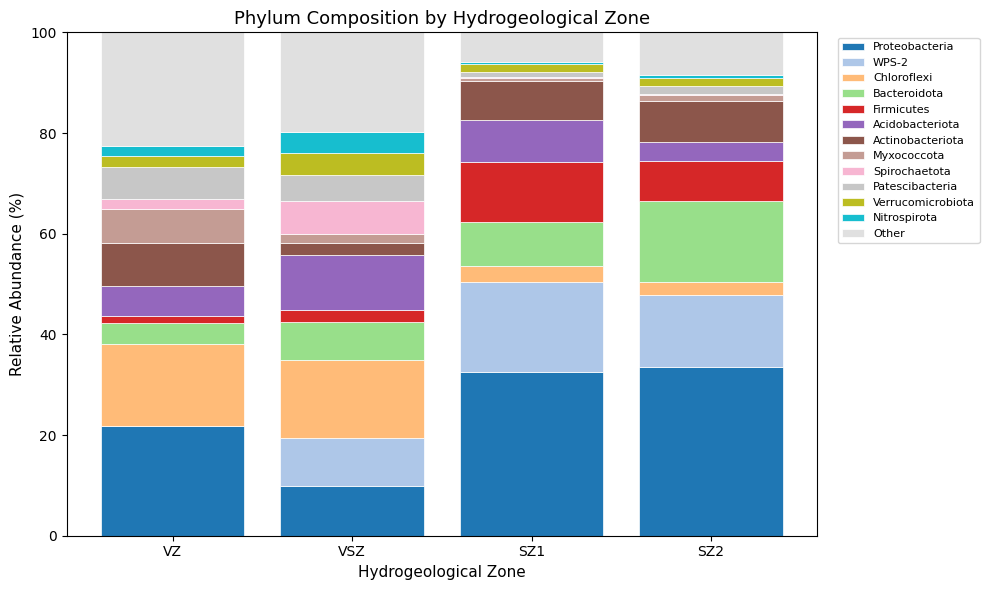

Saved: figures/phylum_by_zone.png


In [6]:
# Load raw sediment ASV data for phylum-level analysis
sed = pd.read_parquet(DATA / 'sso_sediment_asv.parquet')
zone_info = pd.read_csv(DATA / 'sediment_sample_zones.csv')

# Merge zone info
sed = sed.merge(zone_info[['sample_id', 'zone', 'depth_meter']], on='sample_id', how='left')
sed = sed[sed['zone'].isin(ZONE_ORDER)]

# Phylum abundance by zone (aggregated across all wells)
zone_phylum = (sed.dropna(subset=['phylum'])
               .groupby(['zone', 'phylum'])['abundance'].sum()
               .reset_index())
zone_totals = zone_phylum.groupby('zone')['abundance'].sum()
zone_phylum['rel_abund'] = zone_phylum.apply(
    lambda r: r['abundance'] / zone_totals[r['zone']], axis=1)

# Top phyla (>2% in any zone)
top_phyla = (zone_phylum.groupby('phylum')['rel_abund'].max()
             .sort_values(ascending=False)
             .head(12).index.tolist())

# Stacked bar chart by zone
fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(ZONE_ORDER))
cmap = plt.cm.tab20

for i, phylum in enumerate(top_phyla):
    vals = []
    for zone in ZONE_ORDER:
        row = zone_phylum[(zone_phylum['zone'] == zone) & (zone_phylum['phylum'] == phylum)]
        vals.append(row['rel_abund'].values[0] * 100 if len(row) > 0 else 0)
    ax.bar(ZONE_ORDER, vals, bottom=bottom, label=phylum, color=cmap(i / len(top_phyla)),
           edgecolor='white', linewidth=0.5)
    bottom += vals

# "Other" category
other = 100 - bottom
ax.bar(ZONE_ORDER, other, bottom=bottom, label='Other', color='#E0E0E0',
       edgecolor='white', linewidth=0.5)

ax.set_ylabel('Relative Abundance (%)', fontsize=11)
ax.set_xlabel('Hydrogeological Zone', fontsize=11)
ax.set_title('Phylum Composition by Hydrogeological Zone', fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=1)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(FIG / 'phylum_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/phylum_by_zone.png")

## 5. Zone Indicator Taxa

Identify phyla and genera that are significantly enriched or depleted in specific zones. These indicator taxa reveal the functional implications of depth zonation.

In [7]:
# Compute phylum relative abundance per sample, then test for zone associations
sample_phylum = (sed.dropna(subset=['phylum'])
                 .groupby(['sample_id', 'phylum'])['abundance'].sum()
                 .reset_index())

# Add zone info
sample_phylum = sample_phylum.merge(zone_info[['sample_id', 'zone']], on='sample_id')
sample_phylum = sample_phylum[sample_phylum['zone'].isin(ZONE_ORDER)]

# Compute relative abundance per sample
sample_totals = sample_phylum.groupby('sample_id')['abundance'].transform('sum')
sample_phylum['rel_abund'] = sample_phylum['abundance'] / sample_totals

# For each phylum: Kruskal-Wallis across zones, then Spearman with depth order
zone_rank = {'VZ': 0, 'VSZ': 1, 'SZ1': 2, 'SZ2': 3}
indicators = []

for phylum in top_phyla:
    pdata = sample_phylum[sample_phylum['phylum'] == phylum]
    
    # Get values per zone
    zone_vals = {}
    for z in ZONE_ORDER:
        vals = pdata[pdata['zone'] == z]['rel_abund'].values
        zone_vals[z] = vals if len(vals) > 0 else np.array([0.0])
    
    # Kruskal-Wallis
    try:
        h_stat, kw_p = kruskal(*[zone_vals[z] for z in ZONE_ORDER if len(zone_vals[z]) > 0])
    except ValueError:
        h_stat, kw_p = 0, 1.0
    
    # Spearman with depth rank
    all_vals = pdata['rel_abund'].values
    all_ranks = pdata['zone'].map(zone_rank).values
    if len(all_vals) > 3:
        rho, sp_p = spearmanr(all_ranks, all_vals)
    else:
        rho, sp_p = 0, 1.0
    
    # Mean per zone
    means = {z: np.mean(zone_vals[z]) * 100 for z in ZONE_ORDER}
    
    indicators.append({
        'phylum': phylum,
        'kw_H': round(h_stat, 2),
        'kw_p': round(kw_p, 4),
        'depth_rho': round(rho, 3),
        'depth_p': round(sp_p, 4),
        'mean_VZ': round(means['VZ'], 2),
        'mean_VSZ': round(means['VSZ'], 2),
        'mean_SZ1': round(means['SZ1'], 2),
        'mean_SZ2': round(means['SZ2'], 2),
        'trend': '↑deep' if rho > 0.15 else ('↑shallow' if rho < -0.15 else '—'),
    })

ind_df = pd.DataFrame(indicators).sort_values('kw_p')
ind_df.to_csv(DATA / 'zone_indicators.csv', index=False)

print("Zone indicator phyla (sorted by Kruskal-Wallis p-value):")
print(f"{'Phylum':<25} {'H':>6} {'KW p':>8} {'ρ_depth':>8} {'VZ%':>6} {'VSZ%':>6} {'SZ1%':>6} {'SZ2%':>6} {'Trend':>8}")
print("-" * 90)
for _, r in ind_df.iterrows():
    sig = "*" if r['kw_p'] < 0.05 else " "
    print(f"{r['phylum']:<25} {r['kw_H']:>6.1f} {r['kw_p']:>8.4f}{sig} {r['depth_rho']:>8.3f} "
          f"{r['mean_VZ']:>6.1f} {r['mean_VSZ']:>6.1f} {r['mean_SZ1']:>6.1f} {r['mean_SZ2']:>6.1f} {r['trend']:>8}")

Zone indicator phyla (sorted by Kruskal-Wallis p-value):
Phylum                         H     KW p  ρ_depth    VZ%   VSZ%   SZ1%   SZ2%    Trend
------------------------------------------------------------------------------------------
Firmicutes                  24.1   0.0000*    0.756    1.4    2.4   12.0    7.8    ↑deep
Chloroflexi                 21.3   0.0001*   -0.729   16.3   15.5    3.2    2.5 ↑shallow
Patescibacteria             22.0   0.0001*   -0.706    6.4    5.1    1.1    1.6 ↑shallow
Spirochaetota               20.6   0.0001*   -0.501    2.0    6.5    0.1    0.3 ↑shallow
Myxococcota                 19.8   0.0002*   -0.560    6.8    1.8    0.7    1.1 ↑shallow
Proteobacteria              18.0   0.0004*    0.488   21.7    9.9   32.4   33.5    ↑deep
WPS-2                       17.4   0.0006*    0.492    0.0    9.9   20.3   14.4    ↑deep
Actinobacteriota            14.5   0.0023*    0.191    8.5    2.5    7.6    8.2    ↑deep
Verrucomicrobiota           14.2   0.0027*   -0.368 

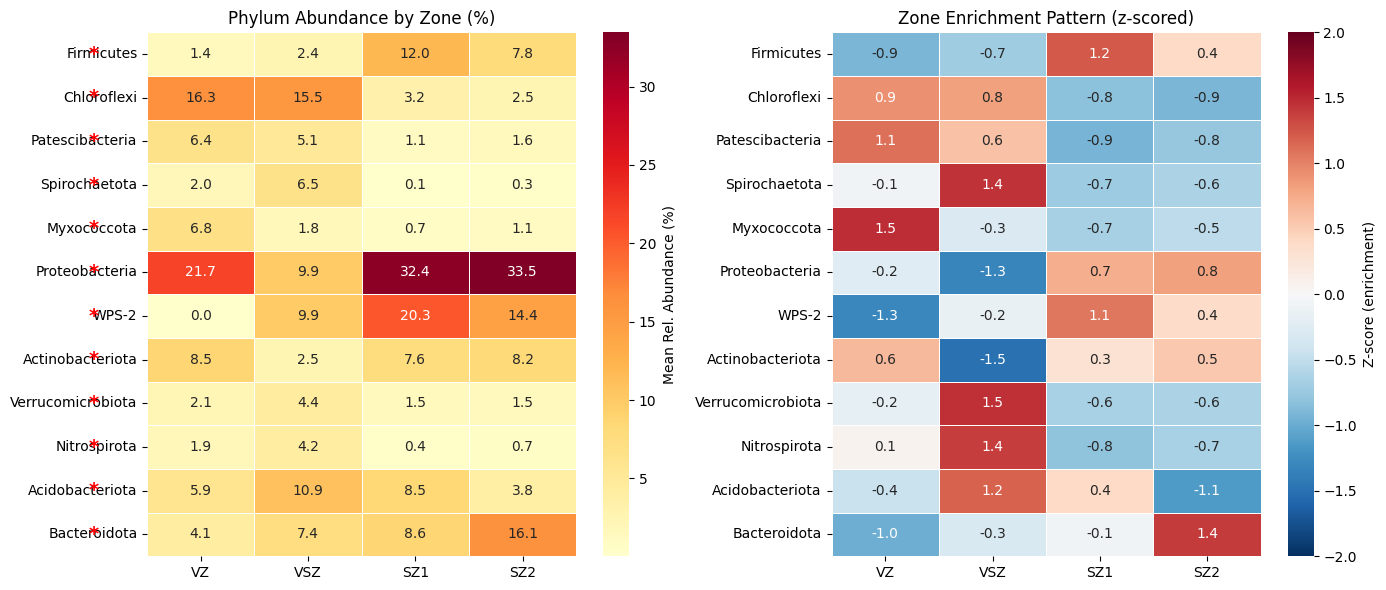

Saved: figures/zone_indicator_heatmap.png
* = Kruskal-Wallis p < 0.05


In [8]:
# Heatmap of top phyla across zones (z-scored for visual clarity)
ind_means = ind_df.set_index('phylum')[['mean_VZ', 'mean_VSZ', 'mean_SZ1', 'mean_SZ2']]
ind_means.columns = ZONE_ORDER

# Z-score each phylum across zones to highlight relative enrichment
ind_z = ind_means.subtract(ind_means.mean(axis=1), axis=0).div(ind_means.std(axis=1), axis=0)
ind_z = ind_z.fillna(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1]})

# Panel A: Raw relative abundance
sns.heatmap(ind_means, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax1,
            cbar_kws={'label': 'Mean Rel. Abundance (%)'}, linewidths=0.5)
ax1.set_title('Phylum Abundance by Zone (%)', fontsize=12)
ax1.set_ylabel('')

# Panel B: Z-scored (enrichment pattern)
sns.heatmap(ind_z, annot=True, fmt='.1f', cmap='RdBu_r', center=0, ax=ax2,
            cbar_kws={'label': 'Z-score (enrichment)'}, linewidths=0.5, vmin=-2, vmax=2)
ax2.set_title('Zone Enrichment Pattern (z-scored)', fontsize=12)
ax2.set_ylabel('')

# Mark significant phyla
for i, (_, r) in enumerate(ind_df.iterrows()):
    if r['kw_p'] < 0.05:
        ax1.text(-0.5, i + 0.5, '*', fontsize=14, fontweight='bold', color='red',
                ha='center', va='center')

plt.tight_layout()
plt.savefig(FIG / 'zone_indicator_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/zone_indicator_heatmap.png")
print("* = Kruskal-Wallis p < 0.05")

## 6. Depth-Continuous Correlation

Rather than binning into zones, test whether phylum abundance varies continuously with depth (Spearman correlation). This captures gradients that zone boundaries might miss.

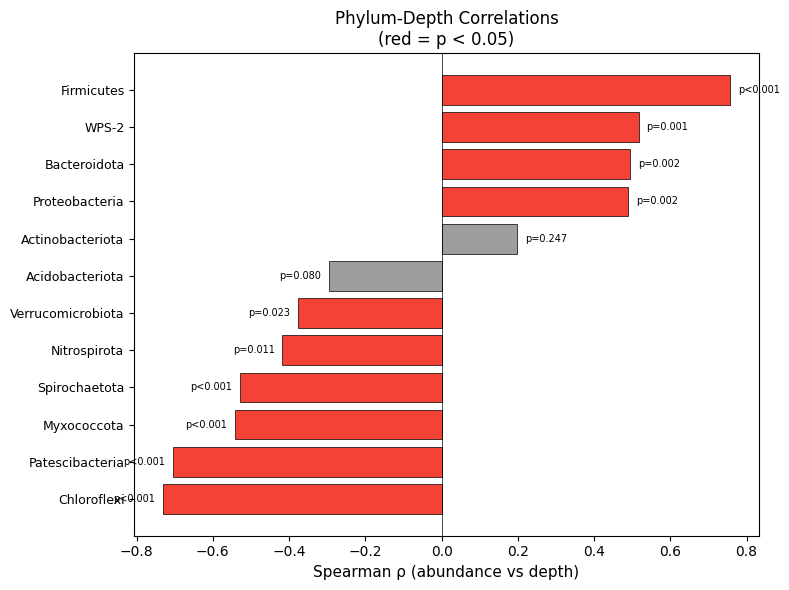

Saved: figures/depth_phylum_correlation.png

Significant depth associations (p < 0.05):
  Chloroflexi: rho=-0.732, p=0.0000 — DECREASES with depth
  Patescibacteria: rho=-0.704, p=0.0000 — DECREASES with depth
  Myxococcota: rho=-0.542, p=0.0006 — DECREASES with depth
  Spirochaetota: rho=-0.529, p=0.0009 — DECREASES with depth
  Nitrospirota: rho=-0.417, p=0.0113 — DECREASES with depth
  Verrucomicrobiota: rho=-0.377, p=0.0233 — DECREASES with depth
  Proteobacteria: rho=0.490, p=0.0024 — INCREASES with depth
  Bacteroidota: rho=0.495, p=0.0021 — INCREASES with depth
  WPS-2: rho=0.517, p=0.0012 — INCREASES with depth
  Firmicutes: rho=0.757, p=0.0000 — INCREASES with depth


In [9]:
# Sample-level phylum relative abundance vs continuous depth
sample_phylum_wide = sample_phylum.pivot_table(
    index='sample_id', columns='phylum', values='rel_abund', fill_value=0)
sample_phylum_wide = sample_phylum_wide.merge(
    zone_info[['sample_id', 'depth_meter']].set_index('sample_id'), 
    left_index=True, right_index=True)

depth_corr = []
for phylum in top_phyla:
    if phylum in sample_phylum_wide.columns:
        rho, p = spearmanr(sample_phylum_wide['depth_meter'], sample_phylum_wide[phylum])
        depth_corr.append({'phylum': phylum, 'rho': rho, 'p': p})

depth_corr_df = pd.DataFrame(depth_corr).sort_values('rho')

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#F44336' if r['p'] < 0.05 else '#9E9E9E' for _, r in depth_corr_df.iterrows()]
bars = ax.barh(range(len(depth_corr_df)), depth_corr_df['rho'].values, color=colors, 
               edgecolor='k', linewidth=0.5)

ax.set_yticks(range(len(depth_corr_df)))
ax.set_yticklabels(depth_corr_df['phylum'].values, fontsize=9)
ax.set_xlabel('Spearman ρ (abundance vs depth)', fontsize=11)
ax.set_title('Phylum-Depth Correlations\n(red = p < 0.05)', fontsize=12)
ax.axvline(x=0, color='k', linewidth=0.5)

# Annotate p-values
for i, (_, r) in enumerate(depth_corr_df.iterrows()):
    label = f"p={r['p']:.3f}" if r['p'] >= 0.001 else "p<0.001"
    ax.text(r['rho'] + (0.02 if r['rho'] >= 0 else -0.02), i, label, 
            fontsize=7, va='center', ha='left' if r['rho'] >= 0 else 'right')

plt.tight_layout()
plt.savefig(FIG / 'depth_phylum_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/depth_phylum_correlation.png")

# Print significant depth associations
print("\nSignificant depth associations (p < 0.05):")
for _, r in depth_corr_df.iterrows():
    if r['p'] < 0.05:
        direction = "INCREASES with depth" if r['rho'] > 0 else "DECREASES with depth"
        print(f"  {r['phylum']}: rho={r['rho']:.3f}, p={r['p']:.4f} — {direction}")

## 7. Summary

In [10]:
print("=" * 60)
print("NB03 DEPTH ZONATION SUMMARY")
print("=" * 60)

print(f"\n1. PERMANOVA VARIANCE PARTITIONING")
print(f"   Zone effect:  R² = {zone_result['R2']*100:.1f}%, F = {zone_result['F']:.2f}, p = {zone_result['p']:.4f}")
print(f"   Well effect:  R² = {well_result['R2']*100:.1f}%, F = {well_result['F']:.2f}, p = {well_result['p']:.4f}")
winner = "ZONE" if zone_result['R2'] > well_result['R2'] else "WELL"
print(f"   → {winner} explains more variance")

print(f"\n2. WITHIN-GROUP DISSIMILARITY")
print(f"   Same well, diff zone:  median BC = {np.median(sw_dz):.3f}")
print(f"   Same zone, diff well:  median BC = {np.median(sz_dw):.3f}")

print(f"\n3. SAMPLE-LEVEL NMDS")
print(f"   Stress = {stress:.4f}")

print(f"\n4. DEPTH-ASSOCIATED PHYLA (p < 0.05)")
for _, r in depth_corr_df.iterrows():
    if r['p'] < 0.05:
        direction = "↑deep" if r['rho'] > 0 else "↑shallow"
        print(f"   {r['phylum']:<25} rho={r['rho']:+.3f}  {direction}")

print(f"\nFiles saved:")
print(f"  data/permanova_results.csv")
print(f"  data/zone_indicators.csv")
print(f"  figures/zone_vs_well_dissim.png")
print(f"  figures/nmds_samples_zone_well.png")
print(f"  figures/phylum_by_zone.png")
print(f"  figures/zone_indicator_heatmap.png")
print(f"  figures/depth_phylum_correlation.png")

NB03 DEPTH ZONATION SUMMARY

1. PERMANOVA VARIANCE PARTITIONING
   Zone effect:  R² = 27.5%, F = 4.05, p = 0.0001
   Well effect:  R² = 19.2%, F = 0.80, p = 0.9785
   → ZONE explains more variance

2. WITHIN-GROUP DISSIMILARITY
   Same well, diff zone:  median BC = 0.977
   Same zone, diff well:  median BC = 0.835

3. SAMPLE-LEVEL NMDS
   Stress = 0.1097

4. DEPTH-ASSOCIATED PHYLA (p < 0.05)
   Chloroflexi               rho=-0.732  ↑shallow
   Patescibacteria           rho=-0.704  ↑shallow
   Myxococcota               rho=-0.542  ↑shallow
   Spirochaetota             rho=-0.529  ↑shallow
   Nitrospirota              rho=-0.417  ↑shallow
   Verrucomicrobiota         rho=-0.377  ↑shallow
   Proteobacteria            rho=+0.490  ↑deep
   Bacteroidota              rho=+0.495  ↑deep
   WPS-2                     rho=+0.517  ↑deep
   Firmicutes                rho=+0.757  ↑deep

Files saved:
  data/permanova_results.csv
  data/zone_indicators.csv
  figures/zone_vs_well_dissim.png
  figures/nmd